In [1]:
pip install torch torchvision pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

### CONSTANTS

In [3]:
torch.seed = 42

QSupply = 1000 #goods

N_producers = 100
N_consumers = N_producers * 10 # 10 times as much as there are producers

DEVICE = (
    torch.device("mps")  if torch.backends.mps.is_available()  else
    torch.device("cuda") if torch.cuda.is_available()          else
    torch.device("cpu")
)

print(f"Device : {DEVICE}")

Device : mps


#### Value defenitions

Producer_parameters = ['Qsupply', 'Mcost', 'FOP', 'price', 'willingness_to_sell_at_price']

Producer_resutls = ['profit', 'PS', 'QS']

#

#Mcost = random value, changed by FOP 

#Qsupply = same initial value, then multiplied by FOP

#FOP = random 0-1 for each and then AVG.

#


Consumer_parameters = ['purchasing_power', 'willingness_to_buy_at_price']

Producer_resutls = ['QD', 'PD']

### Define Producers and Consumers

In [4]:
# PRODUCERS
Producers = {
    "Mcost":   torch.rand(N_producers, device=DEVICE) * 10 + 5,
    "Qsupply": torch.rand(N_producers, device=DEVICE) * 40 + 20,
    "FOP":     torch.rand(N_producers, device=DEVICE) * 120 + 20,
    "price":   torch.zeros(N_producers, device=DEVICE),
    "WTS":     torch.rand(N_producers, device=DEVICE),
}

Consumers = {
    "P_P": torch.rand(N_consumers, device=DEVICE) * 200,
    "WTB": torch.rand(N_consumers, device=DEVICE),
}

Producers, Consumers 

({'Mcost': tensor([ 8.4386, 13.4002,  6.0923,  5.5265,  5.3843, 13.9481,  7.7212,  7.1404,
          12.4529,  8.4044, 14.3122, 11.4035,  7.6651,  5.1543,  8.7522, 12.2913,
           6.9416, 10.1648,  5.8738, 14.1161, 12.7053, 14.0621, 13.1076,  7.3585,
          14.6514,  7.2962, 10.8841,  6.6416, 12.1600, 10.9295,  9.9563, 10.3761,
          10.2360, 13.2683,  6.4902,  5.7290,  8.3672,  7.7518, 11.1825,  5.9907,
          12.0369,  8.0755,  9.5201, 14.5139, 10.1392, 13.2006,  6.5672,  6.9730,
           9.0104,  8.4780, 11.7885,  6.7147, 12.9043,  7.2906,  6.7011, 14.4910,
          11.5039, 13.4238, 10.2694,  6.0675, 11.4144, 14.1027, 13.6476,  6.6677,
          13.9807, 10.7882,  5.0300,  5.2296, 11.8210, 14.1871,  8.1030, 11.3940,
           9.1352, 13.2763, 11.0869,  6.5507, 10.7130, 12.7524, 13.5308,  5.7422,
           5.3031,  6.2240, 12.0759, 11.5876,  8.4297, 11.9835,  8.5115, 10.8108,
           7.7853, 14.8889, 11.6693,  6.5728, 13.0028,  8.4218,  8.1890,  8.3187,
       

### Define Steps

In [5]:
#Producer step 

def producer_step(Producers, market_price):
    
    # 1. Compute each producer's minimum acceptable price (PD)
    PS = Producers["Mcost"] * (1 + Producers["WTS"])

    # 2. Update the price field in the dict
    Producers["price"] = PS
    
    # 3. Decide who is willing to sell
    willing = (market_price >= PS).float()

    # 4. Compute units supplied (SD)
    margin = (market_price - Producers["Mcost"]) / Producers["Mcost"]
    margin = torch.clamp(margin, min=0.0, max=1.0)

    QS = (willing * Producers["Qsupply"] * margin)

    # 5. Compute profit per producer
    profit = (market_price - Producers["Mcost"]) * QS - Producers["FOP"]

    return {"PS": PS, "QS": QS, "profit": profit}


# Consumer step #######################################

def consumer_step(Consumers, market_price): 

    # Step 1: price demanded
    PD = Consumers['P_P'] * Consumers['WTB']

    # Step 2: quantity demanded
    buys = (market_price <= PD).float()
    
    QD = buys * torch.floor(Consumers["P_P"] / market_price)
    
    return {"PD": PD, "QD": QD}


#Clear func #######################################

def clear_market(Producers, Consumers, max_iterations=400):

    # 1. Start with a price guess (work in log space for stability)
    log_p = torch.tensor(3.5, device=DEVICE)  # exp(3.5) ≈ 33

    for i in range(max_iterations):

        # 2. Convert log price to actual price
        market_price = torch.exp(log_p)

        # 3. Get producer and consumer decisions at this price
        p_results = producer_step(Producers, market_price)
        c_results = consumer_step(Consumers, market_price)

        # 4. Compute total supply and total demand
        total_QS = p_results["QS"].sum()
        total_QD = c_results["QD"].sum()

        # 5. Compute excess demand (positive = too much demand = raise price)
        excess = total_QD - total_QS

        # 6. Nudge the price up or down based on excess
        #    hint: log_p = log_p + some_step * torch.tanh(excess / total_QS)
        log_p = log_p + 0.03 * torch.tanh(excess / (total_QS + + 1e-8))

        # 7. Check if we're close enough to stop
        if abs(excess.item()) < 0.5:
            break

    # 8. Return the equilibrium price and final results
    return market_price, p_results, c_results

clear_market(Producers, Consumers)

(tensor(21.9785, device='mps:0'),
 {'PS': tensor([14.6835, 18.7032,  9.2732,  6.1931,  8.7517, 24.1242, 10.9686,  9.9289,
          23.2004, 13.0142, 17.2078, 13.9298,  8.8473,  9.2527, 15.9025, 15.5273,
          12.5483, 16.5953, 11.1964, 17.4977, 18.5701, 24.6505, 13.8261,  9.4823,
          20.4729, 10.5344, 20.7582,  6.8352, 22.9528, 14.2273, 17.3043, 14.7405,
          11.7213, 24.8964,  9.9162,  9.6451, 13.0757, 10.4978, 14.8023,  9.0007,
          20.2072, 14.9400, 16.8651, 15.4264, 17.7275, 25.2474, 12.5574, 12.5867,
          16.3022, 16.3183, 17.2091, 10.7377, 13.6470, 12.0249,  8.9312, 16.8352,
          16.1332, 19.8232, 16.3965,  6.4365, 13.2155, 26.3076, 25.5711,  7.0887,
          19.2500, 19.5406,  9.9235,  7.0260, 11.8850, 23.9441, 10.7260, 19.7088,
          15.5780, 19.1065, 12.2202,  8.2675, 16.4555, 20.9595, 19.4698,  7.7555,
           8.9943, 11.1039, 24.1316, 16.4909, 11.3191, 16.2014,  8.9846, 14.5422,
          14.6348, 28.7913, 20.2656,  7.3906, 22.1496, 11.

### Results

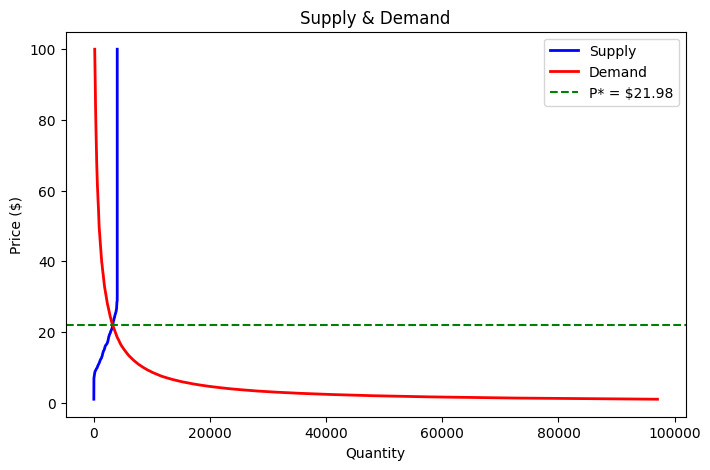


Equilibrium price : $21.98
Total QS          : 4029
Total QD          : 152
Avg producer profit: $3554.91
Producers supplying: 100 / 100
Consumers buying   : 152 / 1000


In [9]:
price_range = torch.linspace(1, 100, 300, device=DEVICE)
eq_price, p_res, c_res = clear_market(Producers, Consumers)

supply_curve = []
demand_curve = []

for p in price_range:
    p_res = producer_step(Producers, p)
    c_res = consumer_step(Consumers, p)
    supply_curve.append(p_res["QS"].sum().item())
    demand_curve.append(c_res["QD"].sum().item())


prices = price_range.cpu().numpy()
supply = np.array(supply_curve)
demand = np.array(demand_curve)


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(supply, prices , color="blue", lw=2, label="Supply")
ax.plot(demand, prices, color="red",  lw=2, label="Demand")


ax.axhline(y=eq_price.item(), color="green", ls="--", lw=1.5, label=f"P* = ${eq_price.item():.2f}")

ax.set_ylabel("Price ($)")
ax.set_xlabel("Quantity")
ax.set_title("Supply & Demand")
ax.legend()
plt.show()

print()

print(f"Equilibrium price : ${eq_price.item():.2f}")
print(f"Total QS          : {p_res['QS'].sum().item():.0f}")
print(f"Total QD          : {c_res['QD'].sum().item():.0f}")
print(f"Avg producer profit: ${p_res['profit'].mean().item():.2f}")
print(f"Producers supplying: {(p_res['QS'] > 0).sum().item()} / {N_producers}")
print(f"Consumers buying   : {(c_res['QD'] > 0).sum().item()} / {N_consumers}")

## Vary initial conditions

### Constants

In [ ]:
Vary_by  = torch.rand(1, device=DEVICE)

In [ ]:
# PRODUCERS
Producers1 = {
    "Mcost":   torch.rand(N_producers, device=DEVICE) * (10 + 5) * Vary_by,
    "Qsupply": torch.rand(N_producers, device=DEVICE) * (40 + 20) * Vary_by,
    "FOP":     torch.rand(N_producers, device=DEVICE) * (120 + 20) * Vary_by,
    "price":   torch.zeros(N_producers, device=DEVICE),
    "WTS":     torch.rand(N_producers, device=DEVICE),
}

Consumers1 = {
    "P_P": torch.rand(N_consumers, device=DEVICE) * (200)  * Vary_by,
    "WTB": torch.rand(N_consumers, device=DEVICE),
}

Producers1, Consumers1

({'Mcost': tensor([0.6045, 0.8316, 0.5451, 1.9202, 1.6448, 1.5966, 0.6593, 1.5999, 2.0484,
          0.7710, 1.8765, 1.0485, 0.9264, 0.7395, 0.4787, 0.3307, 0.1169, 0.6336,
          1.5009, 0.4659, 1.7048, 0.2219, 0.8084, 0.5683, 0.5355, 0.0338, 1.9473,
          1.5423, 0.9415, 0.6044, 1.5468, 0.9269, 1.2711, 0.3650, 1.7314, 1.5553,
          1.5371, 0.0308, 1.7697, 1.6307, 0.4715, 0.5508, 0.3335, 0.8341, 1.2943,
          1.1012, 0.7250, 1.2605, 1.8065, 1.3425, 0.8551, 0.2696, 0.3112, 1.5325,
          1.2040, 1.9034, 0.7414, 1.9800, 1.7336, 2.0107, 0.9700, 0.5500, 0.2091,
          1.0008, 0.6712, 0.5808, 0.4523, 1.5765, 0.0221, 0.4658, 1.9976, 1.5896,
          1.8648, 2.0388, 1.1788, 1.9449, 1.6934, 1.8983, 1.2412, 0.2825, 0.3229,
          0.4637, 1.9971, 0.4584, 0.4208, 1.4312, 0.3356, 1.6503, 1.7070, 0.0945,
          1.3315, 0.6943, 2.0463, 1.1242, 1.9124, 1.1811, 1.6154, 0.8312, 0.4304,
          1.6830], device='mps:0'),
  'Qsupply': tensor([7.8403, 6.8618, 4.3805, 3.5618, 

### Results

In [ ]:

results = []


for i in range(40): 
    # PRODUCERS
    Producers1 = {
        "Mcost":   torch.rand(N_producers, device=DEVICE) * (10 + 5) * Vary_by,
        "Qsupply": torch.rand(N_producers, device=DEVICE) * (40 + 20) * Vary_by,
        "FOP":     torch.rand(N_producers, device=DEVICE) * (120 + 20) * Vary_by,
        "price":   torch.zeros(N_producers, device=DEVICE),
        "WTS":     torch.rand(N_producers, device=DEVICE),
    }

    Consumers1 = {
        "P_P": torch.rand(N_consumers, device=DEVICE) * (200)  * Vary_by,
        "WTB": torch.rand(N_consumers, device=DEVICE),
    }
    
    

    price_range = torch.linspace(1, 100, 300, device=DEVICE)

    supply_curve = []
    demand_curve = []

    for p in price_range:
        p_res = producer_step(Producers1, p)
        c_res = consumer_step(Consumers1, p)
        supply_curve.append(p_res["QS"].sum().item())
        demand_curve.append(c_res["QD"].sum().item())


    prices = price_range.cpu().numpy()
    supply = np.array(supply_curve)
    demand = np.array(demand_curve)

    print()

    eq_price, p_res, c_res = clear_market(Producers1, Consumers1)

    # print(f"Equilibrium price : ${eq_price.item():.2f}")
    # print(f"Total QS          : {p_res['QS'].sum().item():.0f}")
    # print(f"Total QD          : {c_res['QD'].sum().item():.0f}")
    # print(f"Avg producer profit: ${p_res['profit'].mean().item():.2f}")
    # print(f"Producers supplying: {(p_res['QS'] > 0).sum().item()} / {N_producers}")
    # print(f"Consumers buying   : {(c_res['QD'] > 0).sum().item()} / {N_consumers}")

    print("Done")

    results.append((Consumers1, Producers1, prices, supply, demand, eq_price.item(), p_res['QS'].sum().item(), c_res['QD'].sum().item(), p_res['profit'].mean().item(),(p_res['QS'] > 0).sum().item(), (c_res['QD'] > 0).sum().item()))


Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done

Done


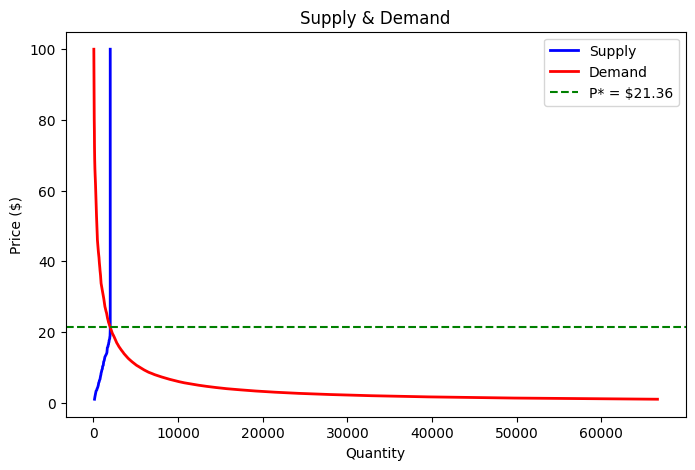

Equilibrium price : $21.36
Total QS          : 1977
Total QD          : 1977
Avg producer profit: $268.31
Producers supplying: 100 / 100
Consumers buying   : 558 / 1000


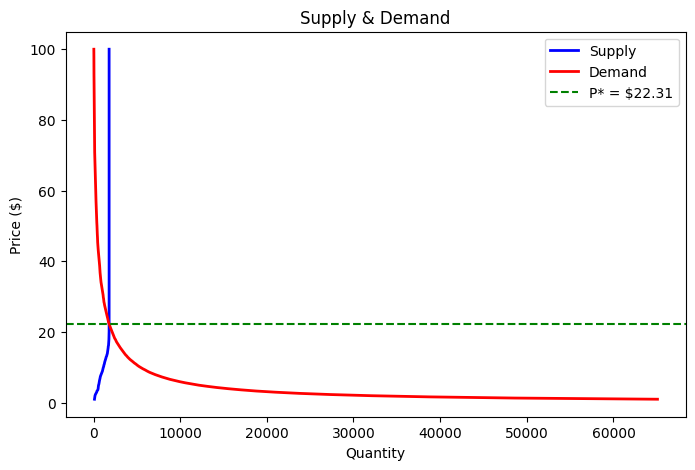

Equilibrium price : $22.31
Total QS          : 1801
Total QD          : 1801
Avg producer profit: $267.56
Producers supplying: 100 / 100
Consumers buying   : 529 / 1000


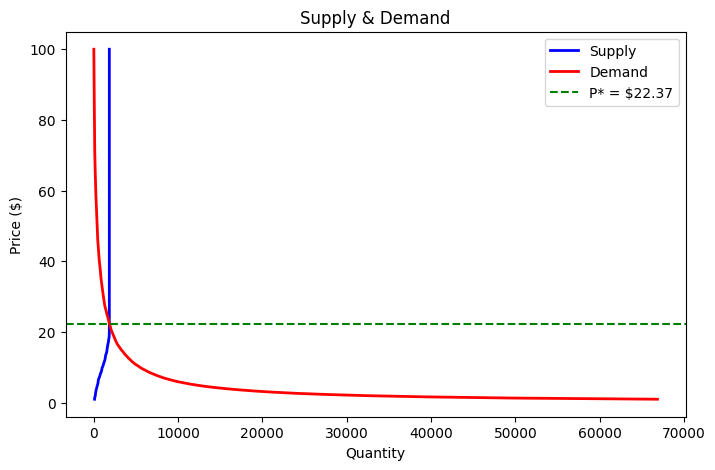

Equilibrium price : $22.37
Total QS          : 1869
Total QD          : 1869
Avg producer profit: $271.51
Producers supplying: 100 / 100
Consumers buying   : 545 / 1000


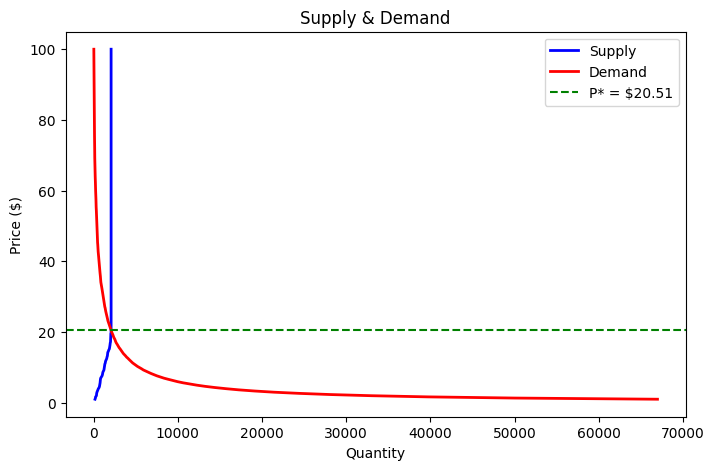

Equilibrium price : $20.51
Total QS          : 2089
Total QD          : 2089
Avg producer profit: $279.14
Producers supplying: 100 / 100
Consumers buying   : 552 / 1000


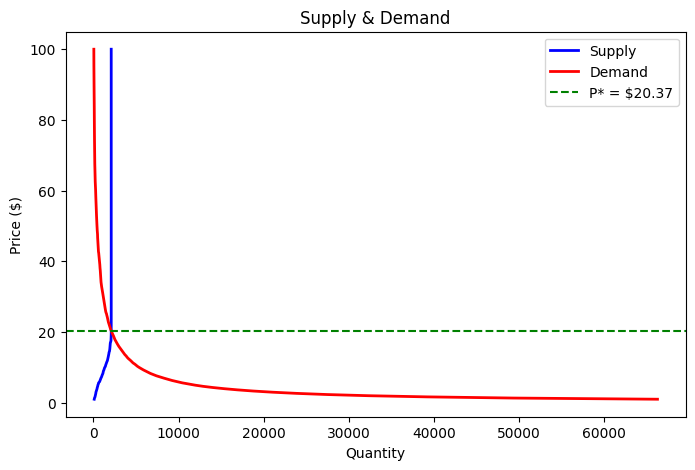

Equilibrium price : $20.37
Total QS          : 2089
Total QD          : 2089
Avg producer profit: $270.98
Producers supplying: 100 / 100
Consumers buying   : 555 / 1000


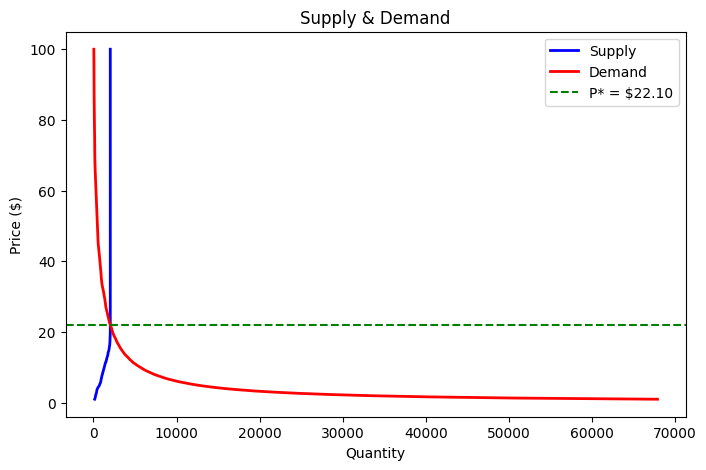

Equilibrium price : $22.10
Total QS          : 2026
Total QD          : 2026
Avg producer profit: $304.07
Producers supplying: 100 / 100
Consumers buying   : 578 / 1000


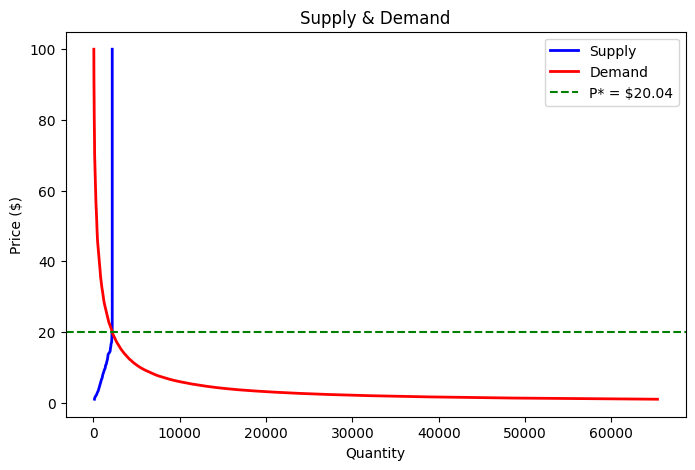

Equilibrium price : $20.04
Total QS          : 2172
Total QD          : 2172
Avg producer profit: $284.43
Producers supplying: 100 / 100
Consumers buying   : 566 / 1000


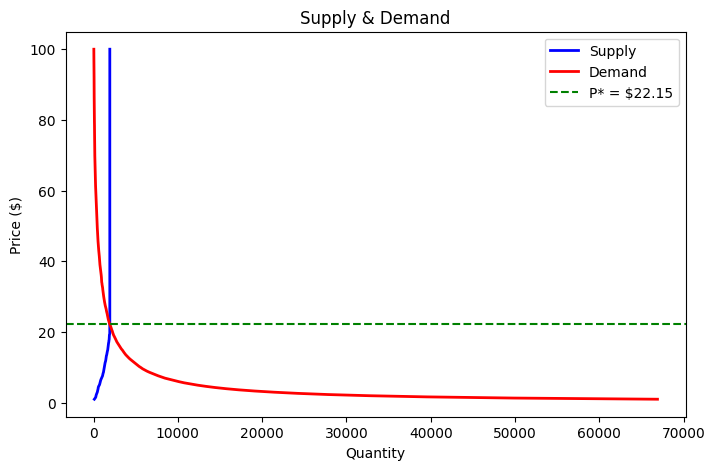

Equilibrium price : $22.15
Total QS          : 1931
Total QD          : 1931
Avg producer profit: $286.61
Producers supplying: 100 / 100
Consumers buying   : 562 / 1000


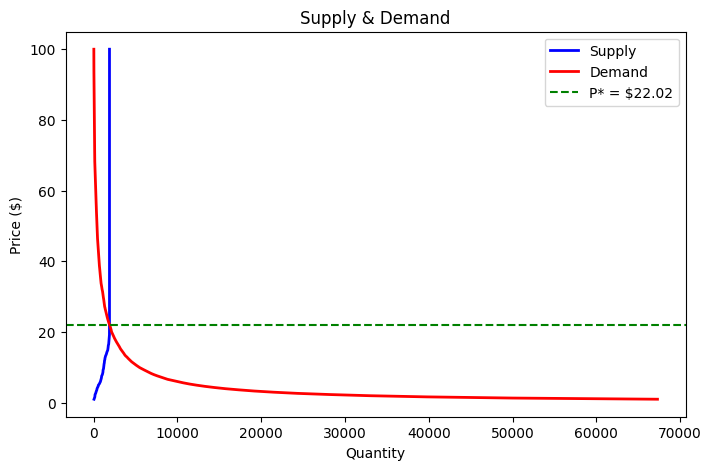

Equilibrium price : $22.02
Total QS          : 1906
Total QD          : 1906
Avg producer profit: $277.75
Producers supplying: 100 / 100
Consumers buying   : 543 / 1000


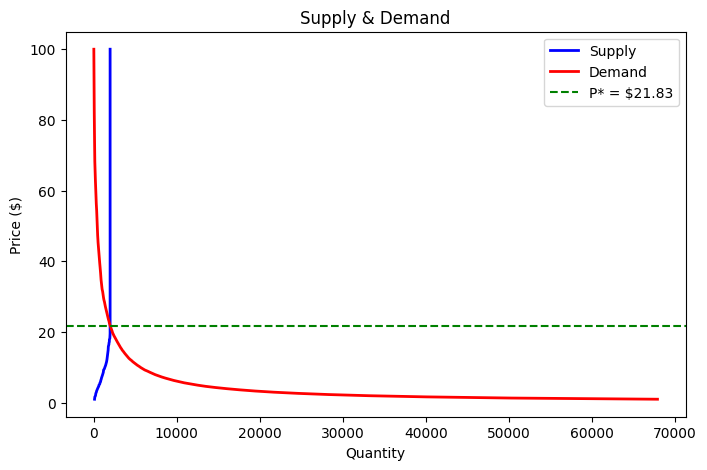

Equilibrium price : $21.83
Total QS          : 1992
Total QD          : 1992
Avg producer profit: $291.33
Producers supplying: 100 / 100
Consumers buying   : 563 / 1000


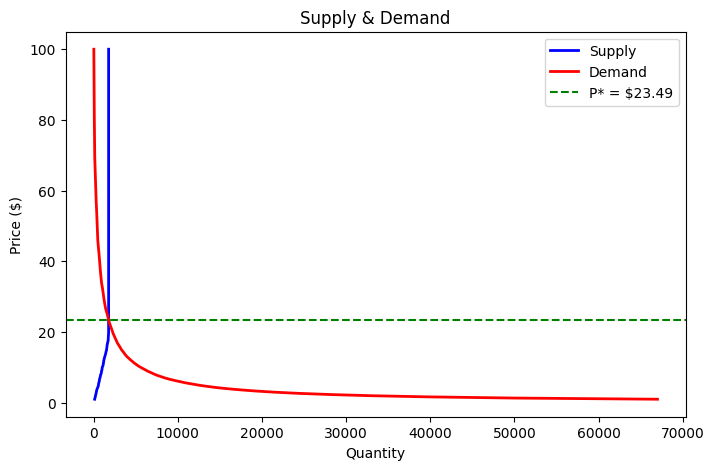

Equilibrium price : $23.49
Total QS          : 1793
Total QD          : 1795
Avg producer profit: $279.58
Producers supplying: 100 / 100
Consumers buying   : 546 / 1000


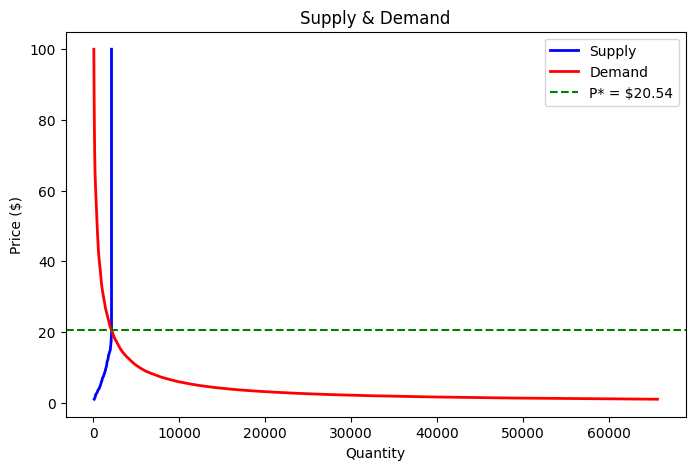

Equilibrium price : $20.54
Total QS          : 2103
Total QD          : 2103
Avg producer profit: $289.76
Producers supplying: 100 / 100
Consumers buying   : 565 / 1000


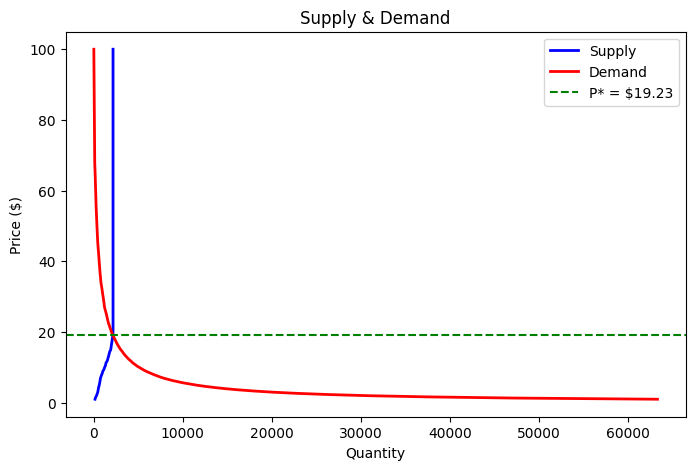

Equilibrium price : $19.23
Total QS          : 2151
Total QD          : 2151
Avg producer profit: $252.28
Producers supplying: 99 / 100
Consumers buying   : 555 / 1000


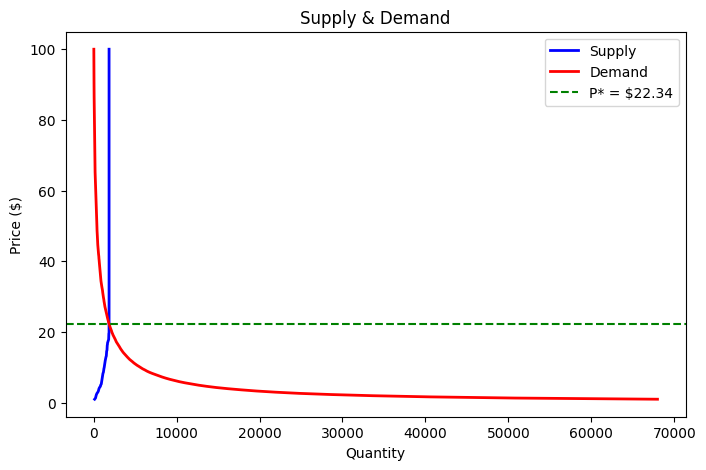

Equilibrium price : $22.34
Total QS          : 1859
Total QD          : 1859
Avg producer profit: $286.79
Producers supplying: 100 / 100
Consumers buying   : 539 / 1000


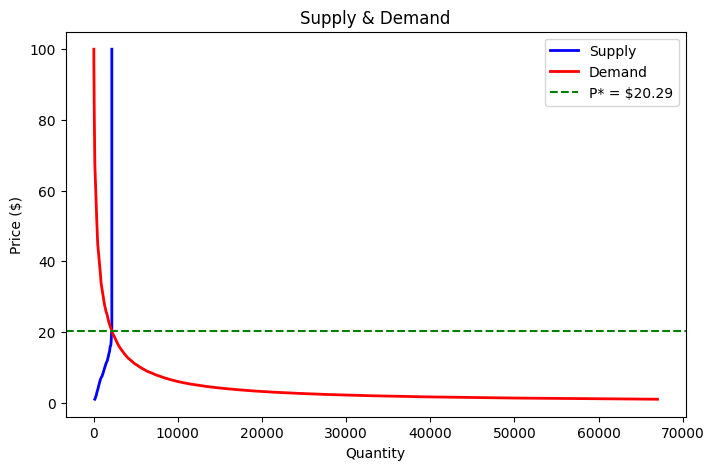

Equilibrium price : $20.29
Total QS          : 2176
Total QD          : 2176
Avg producer profit: $283.62
Producers supplying: 100 / 100
Consumers buying   : 592 / 1000


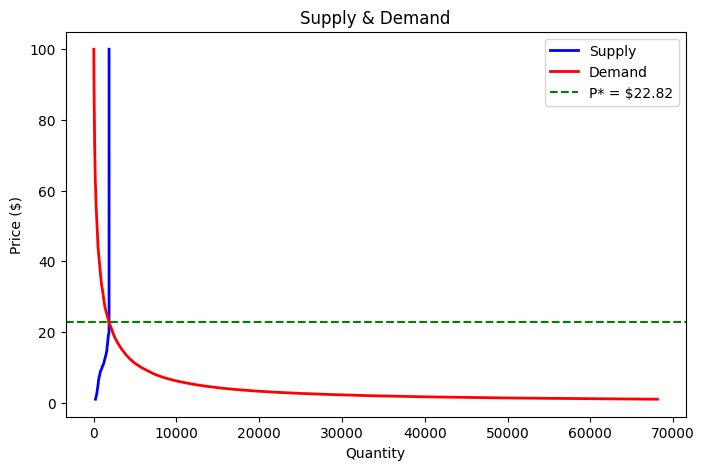

Equilibrium price : $22.82
Total QS          : 1872
Total QD          : 1872
Avg producer profit: $286.49
Producers supplying: 100 / 100
Consumers buying   : 555 / 1000


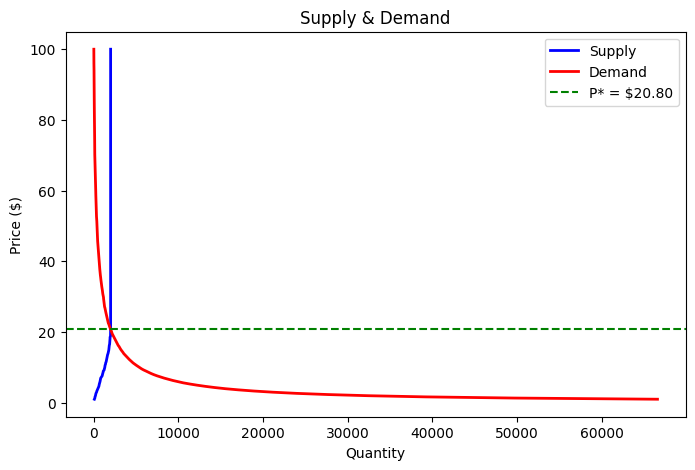

Equilibrium price : $20.80
Total QS          : 2016
Total QD          : 2016
Avg producer profit: $267.22
Producers supplying: 100 / 100
Consumers buying   : 552 / 1000


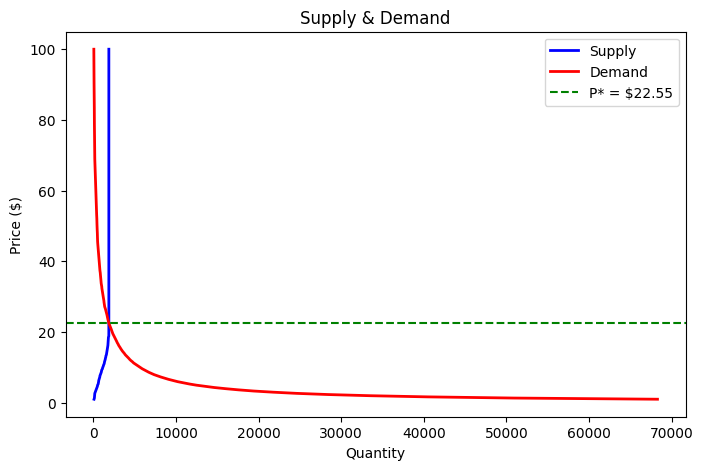

Equilibrium price : $22.55
Total QS          : 1873
Total QD          : 1873
Avg producer profit: $278.21
Producers supplying: 100 / 100
Consumers buying   : 541 / 1000


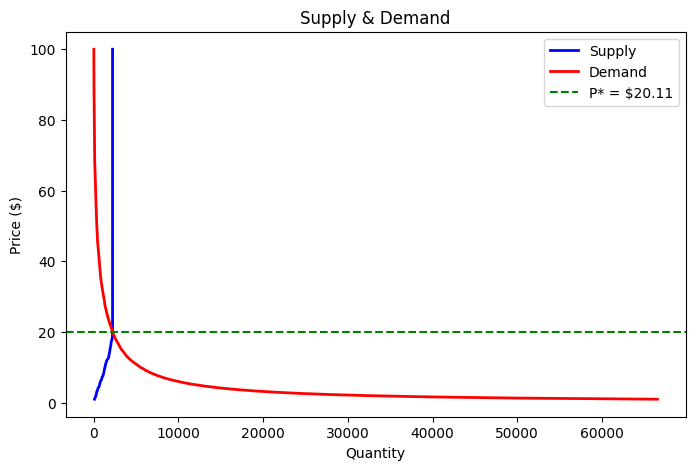

Equilibrium price : $20.11
Total QS          : 2242
Total QD          : 2242
Avg producer profit: $287.45
Producers supplying: 100 / 100
Consumers buying   : 602 / 1000


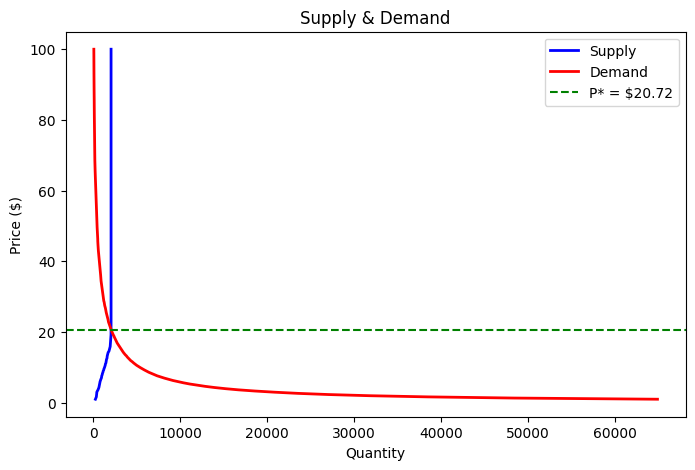

Equilibrium price : $20.72
Total QS          : 2026
Total QD          : 2028
Avg producer profit: $271.93
Producers supplying: 100 / 100
Consumers buying   : 562 / 1000


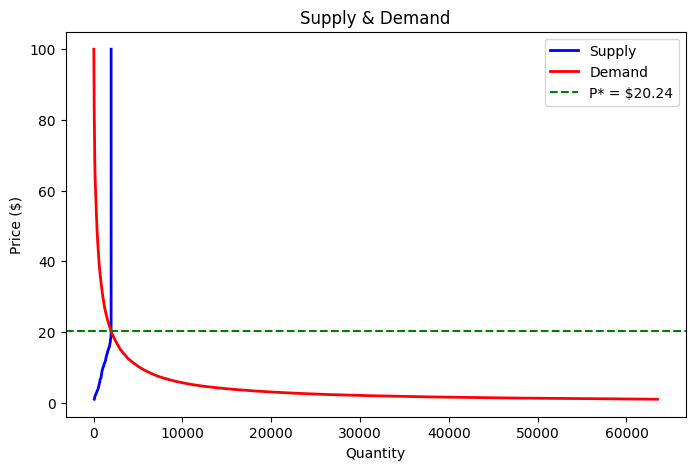

Equilibrium price : $20.24
Total QS          : 1973
Total QD          : 1973
Avg producer profit: $245.98
Producers supplying: 100 / 100
Consumers buying   : 524 / 1000


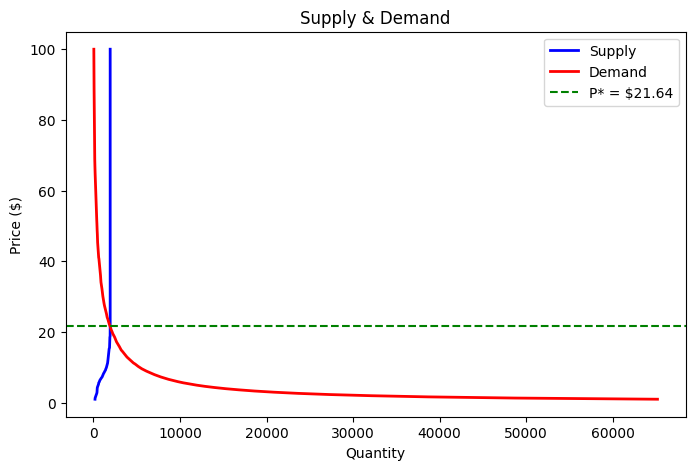

Equilibrium price : $21.64
Total QS          : 1930
Total QD          : 1930
Avg producer profit: $284.07
Producers supplying: 100 / 100
Consumers buying   : 546 / 1000


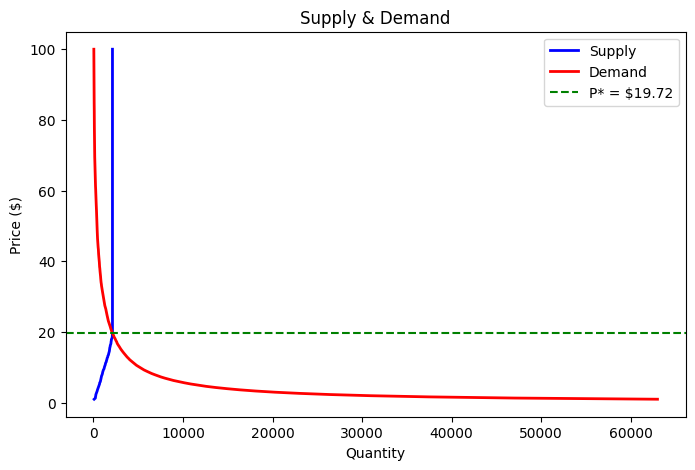

Equilibrium price : $19.72
Total QS          : 2115
Total QD          : 2114
Avg producer profit: $254.86
Producers supplying: 100 / 100
Consumers buying   : 563 / 1000


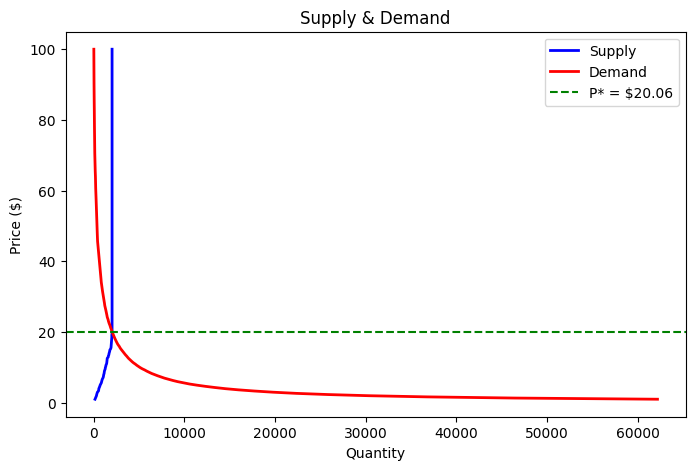

Equilibrium price : $20.06
Total QS          : 2046
Total QD          : 2046
Avg producer profit: $267.07
Producers supplying: 100 / 100
Consumers buying   : 565 / 1000


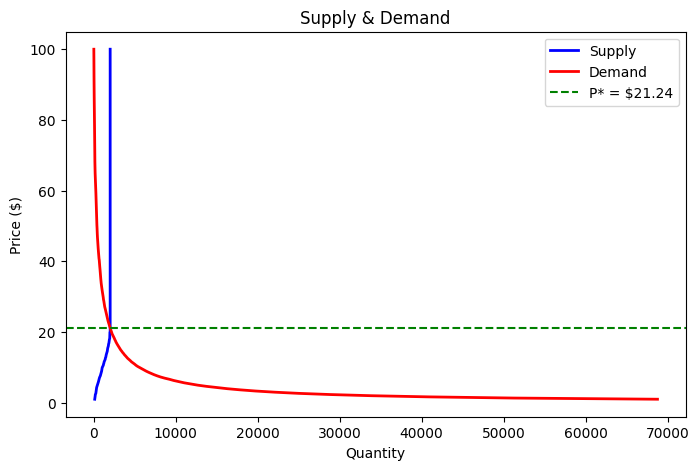

Equilibrium price : $21.24
Total QS          : 2028
Total QD          : 2028
Avg producer profit: $271.32
Producers supplying: 100 / 100
Consumers buying   : 551 / 1000


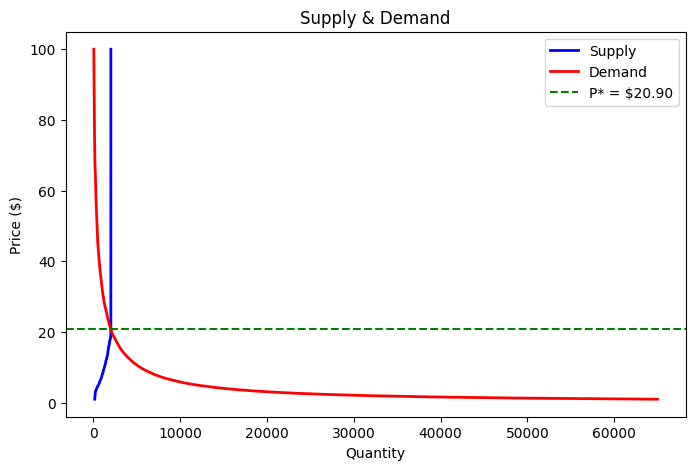

Equilibrium price : $20.90
Total QS          : 2003
Total QD          : 2003
Avg producer profit: $272.91
Producers supplying: 100 / 100
Consumers buying   : 552 / 1000


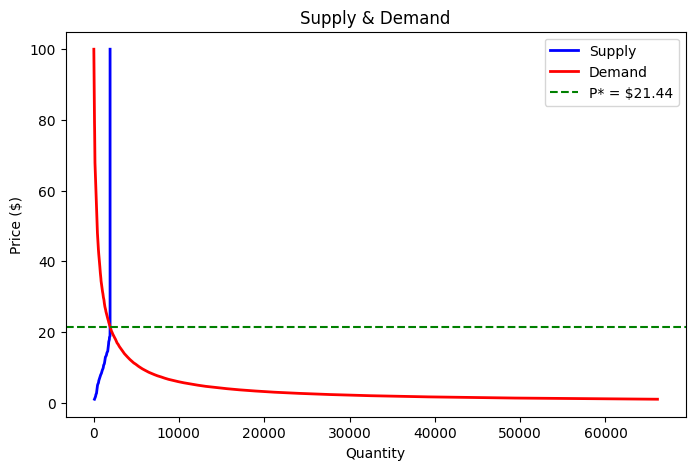

Equilibrium price : $21.44
Total QS          : 1938
Total QD          : 1938
Avg producer profit: $262.70
Producers supplying: 100 / 100
Consumers buying   : 547 / 1000


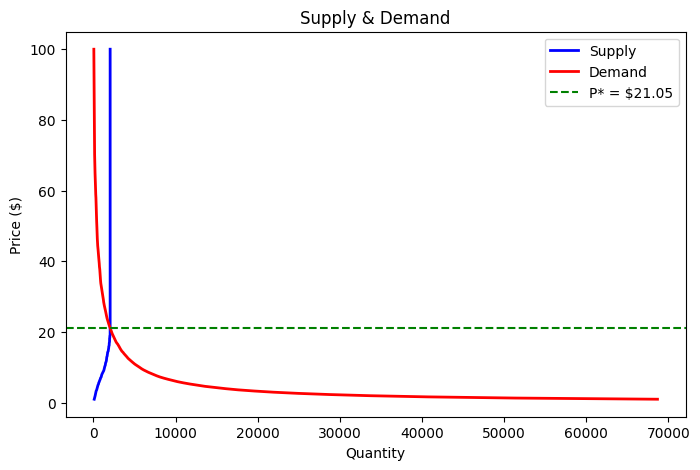

Equilibrium price : $21.05
Total QS          : 2033
Total QD          : 2034
Avg producer profit: $283.18
Producers supplying: 99 / 100
Consumers buying   : 543 / 1000


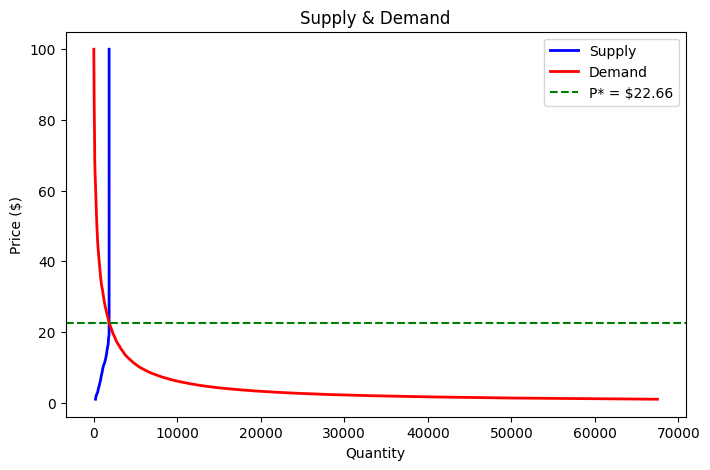

Equilibrium price : $22.66
Total QS          : 1861
Total QD          : 1861
Avg producer profit: $285.62
Producers supplying: 100 / 100
Consumers buying   : 544 / 1000


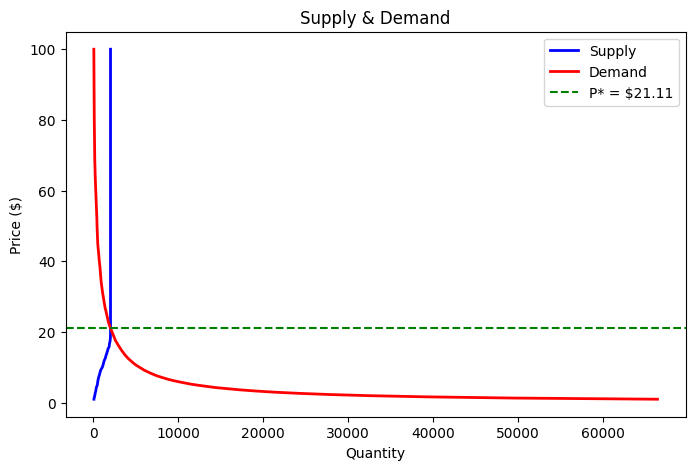

Equilibrium price : $21.11
Total QS          : 2008
Total QD          : 2007
Avg producer profit: $256.99
Producers supplying: 100 / 100
Consumers buying   : 548 / 1000


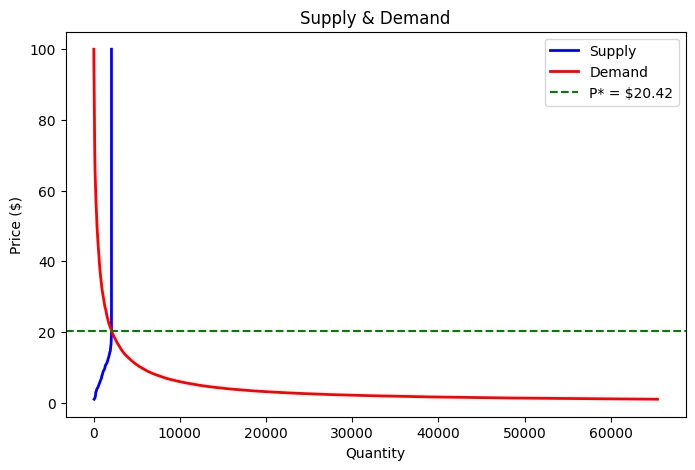

Equilibrium price : $20.42
Total QS          : 2076
Total QD          : 2076
Avg producer profit: $274.51
Producers supplying: 100 / 100
Consumers buying   : 549 / 1000


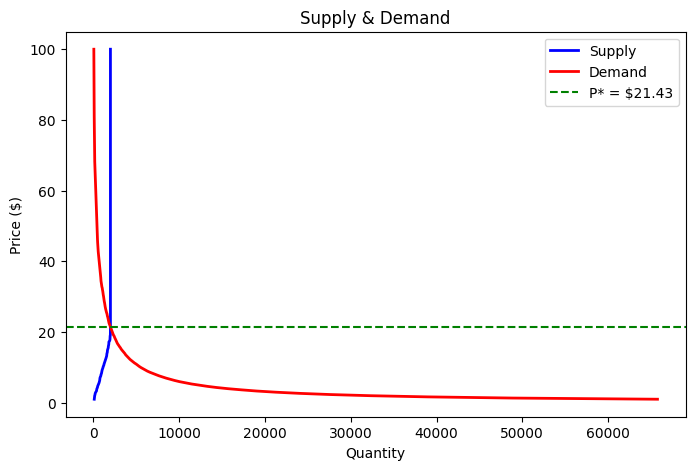

Equilibrium price : $21.43
Total QS          : 1985
Total QD          : 1987
Avg producer profit: $273.18
Producers supplying: 100 / 100
Consumers buying   : 560 / 1000


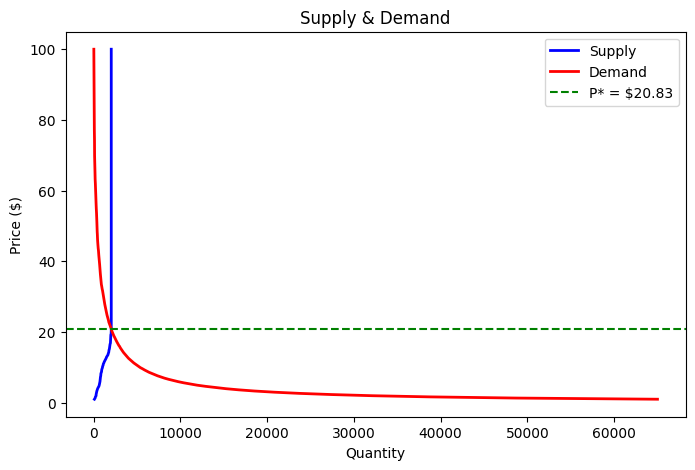

Equilibrium price : $20.83
Total QS          : 2045
Total QD          : 2045
Avg producer profit: $268.64
Producers supplying: 100 / 100
Consumers buying   : 561 / 1000


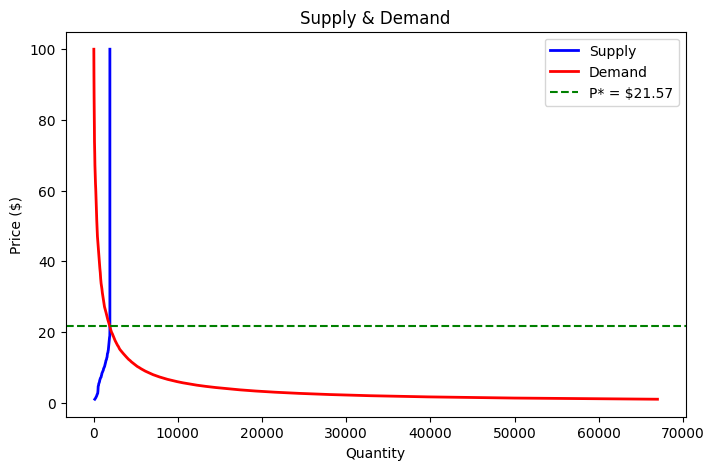

Equilibrium price : $21.57
Total QS          : 1940
Total QD          : 1940
Avg producer profit: $278.41
Producers supplying: 100 / 100
Consumers buying   : 546 / 1000


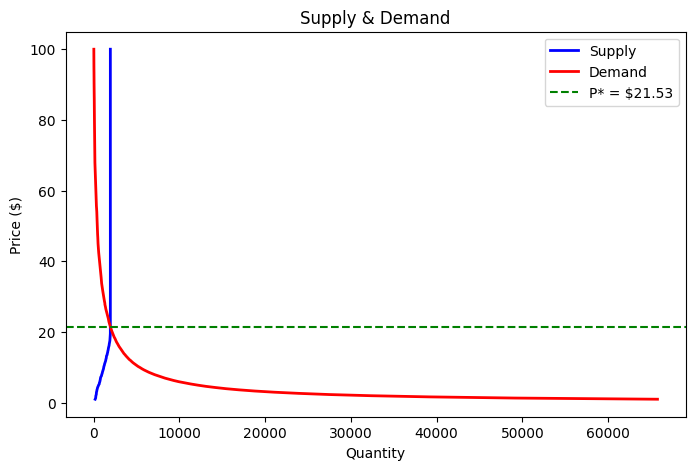

Equilibrium price : $21.53
Total QS          : 1959
Total QD          : 1959
Avg producer profit: $274.31
Producers supplying: 100 / 100
Consumers buying   : 552 / 1000


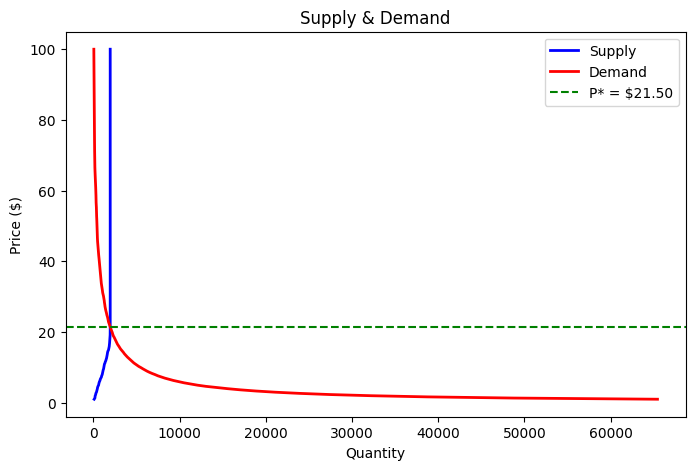

Equilibrium price : $21.50
Total QS          : 1941
Total QD          : 1941
Avg producer profit: $271.86
Producers supplying: 100 / 100
Consumers buying   : 545 / 1000


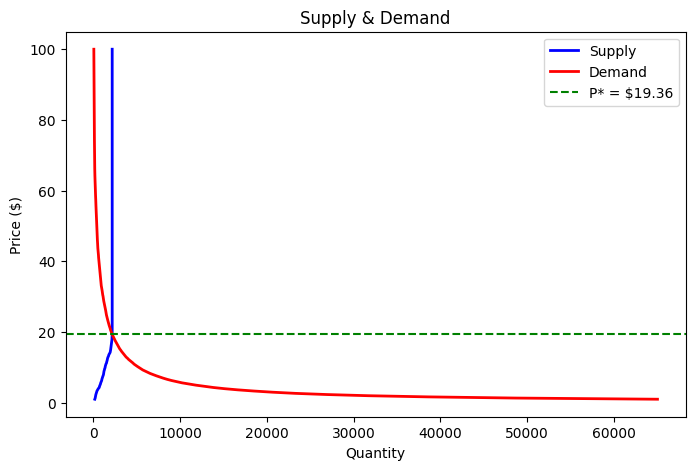

Equilibrium price : $19.36
Total QS          : 2154
Total QD          : 2154
Avg producer profit: $265.25
Producers supplying: 100 / 100
Consumers buying   : 557 / 1000


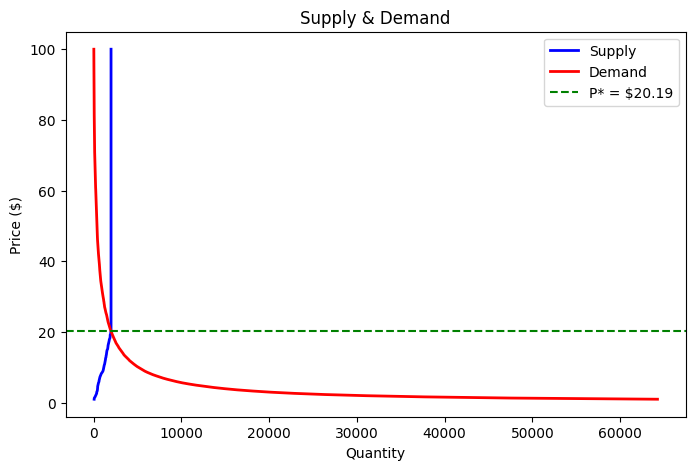

Equilibrium price : $20.19
Total QS          : 1992
Total QD          : 1992
Avg producer profit: $245.10
Producers supplying: 100 / 100
Consumers buying   : 535 / 1000


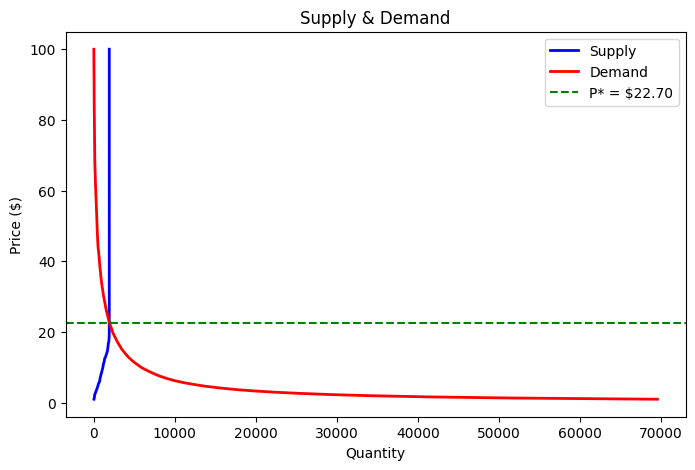

Equilibrium price : $22.70
Total QS          : 1938
Total QD          : 1938
Avg producer profit: $288.85
Producers supplying: 100 / 100
Consumers buying   : 552 / 1000


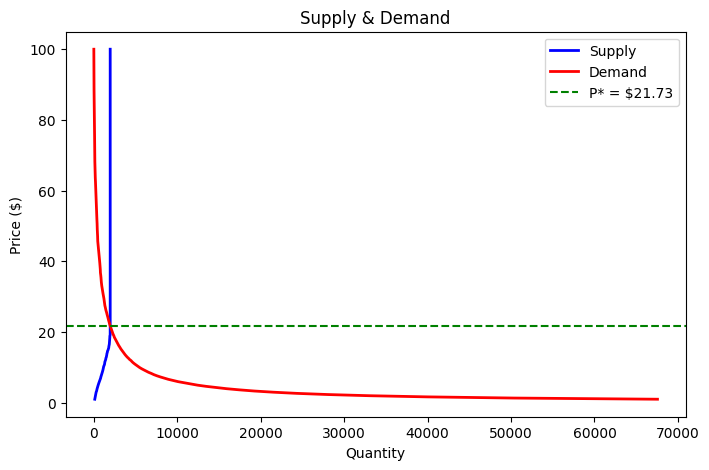

Equilibrium price : $21.73
Total QS          : 1989
Total QD          : 1989
Avg producer profit: $282.42
Producers supplying: 100 / 100
Consumers buying   : 566 / 1000


In [ ]:
for i in results: 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(i[3], i[2] , color="blue", lw=2, label="Supply")
    ax.plot(i[4], i[2], color="red",  lw=2, label="Demand")

    ax.axhline(y=i[5], color="green", ls="--", lw=1.5, label=f"P* = ${i[5]:.2f}")

    ax.set_ylabel("Price ($)")
    ax.set_xlabel("Quantity")
    ax.set_title("Supply & Demand")
    ax.legend()
    plt.show()

    eq_price, p_res, c_res = clear_market(i[1], i[0])

    print(f"Equilibrium price : ${i[5]:.2f}")
    print(f"Total QS          : {i[6]:.0f}")
    print(f"Total QD          : {i[7]:.0f}")
    print(f"Avg producer profit: ${i[8]:.2f}")
    print(f"Producers supplying: {i[9]} / {N_producers}")
    print(f"Consumers buying   : {i[10]} / {N_consumers}")
